In [25]:
# CELL 1 — Imports and Device

import os
import json
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms

from torch.utils.data import DataLoader, Subset, random_split

import timm

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt


SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 60)
print("DEVICE INFORMATION")
print("=" * 60)

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())
print("Using device    :", device)

if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))
    print(
        "CUDA version    :",
        torch.version.cuda
    )

DEVICE INFORMATION
PyTorch version : 2.0.1+cu118
CUDA available  : True
Using device    : cuda
GPU             : NVIDIA GeForce RTX 3050 Laptop GPU
CUDA version    : 11.8


In [26]:
# CELL 2 — Project Configuration

from pathlib import Path

# Repo root: walk up from the notebook's directory until app.py is found.
PROJECT_PATH = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "app.py").is_file())

DATA_PATH = PROJECT_PATH / "datasets" / "KAGGLE DATASET" / "Combined Dataset" / "train"

MODELS_PATH = PROJECT_PATH / "models"

RESULTS_PATH = PROJECT_PATH / "results"

IMG_SIZE_STANDARD = 224
IMG_SIZE_EFFICIENTNET = 380

BATCH_SIZE_STANDARD = 32
BATCH_SIZE_EFFICIENTNET = 16

NUM_CLASSES = 4
SEED = 42

MODEL_PATHS = {
    "ResNet-152": os.path.join(
        MODELS_PATH,
        "resnet152_best.pth"
    ),
    "VGG16": os.path.join(
        MODELS_PATH,
        "vgg16_best.pth"
    ),
    "EfficientNet-B4": os.path.join(
        MODELS_PATH,
        "efficientnet_b4_best.pth"
    ),
    "ViT": os.path.join(
        MODELS_PATH,
        "vit_best.pth"
    )
}

print("=" * 60)
print("PROJECT CONFIGURATION")
print("=" * 60)

print("Project :", PROJECT_PATH)
print("Dataset :", DATA_PATH)
print("Models  :", MODELS_PATH)
print("Results :", RESULTS_PATH)

print("\nFinal checkpoints:")

for name, path in MODEL_PATHS.items():
    print(
        f"{name:<20}: "
        f"{'FOUND' if os.path.isfile(path) else 'NOT FOUND'}"
    )

PROJECT CONFIGURATION
Project : .
Dataset : datasets\KAGGLE DATASET\Combined Dataset\train
Models  : models
Results : results

Final checkpoints:
ResNet-152          : FOUND
VGG16               : FOUND
EfficientNet-B4     : FOUND
ViT                 : FOUND


In [27]:
# CELL 3 — Dataset Setup

train_transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform_380 = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


dataset_raw = datasets.ImageFolder(
    root=DATA_PATH,
    transform=None
)

classes = dataset_raw.classes
total = len(dataset_raw)

train_size = int(0.70 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size

all_indices = list(range(total))

train_subset, val_subset, test_subset = random_split(
    all_indices,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_indices = train_subset.indices
val_indices = val_subset.indices
test_indices = test_subset.indices


dataset_224 = datasets.ImageFolder(
    root=DATA_PATH,
    transform=eval_transform_224
)

dataset_380 = datasets.ImageFolder(
    root=DATA_PATH,
    transform=eval_transform_380
)


print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Classes:", classes)
print("Total images:", total)

print("\nSplit sizes:")
print("Train:", len(train_indices))
print("Validation:", len(val_indices))
print("Test:", len(test_indices))

print("\nInput sizes:")
print("ResNet-152 / VGG16 / ViT: 224")
print("EfficientNet-B4: 380")

DATASET INFORMATION
Classes: ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']
Total images: 10240

Split sizes:
Train: 7168
Validation: 1536
Test: 1536

Input sizes:
ResNet-152 / VGG16 / ViT: 224
EfficientNet-B4: 380


In [28]:
# CELL 4 — Verify Split

train_set = set(train_indices)
val_set = set(val_indices)
test_set = set(test_indices)

print("Split overlap:")
print("Train ∩ Validation:", len(train_set & val_set))
print("Train ∩ Test:", len(train_set & test_set))
print("Validation ∩ Test:", len(val_set & test_set))

print("\nClass distribution:")

for split_name, indices in {
    "Train": train_indices,
    "Validation": val_indices,
    "Test": test_indices
}.items():

    counts = np.bincount(
        [dataset_raw.targets[i] for i in indices],
        minlength=NUM_CLASSES
    )

    print(f"\n{split_name}:")

    for class_name, count in zip(classes, counts):
        print(
            f"{class_name}: "
            f"{count} "
            f"({100 * count / len(indices):.2f}%)"
        )

Split overlap:
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

Class distribution:

Train:
Mild Impairment: 1793 (25.01%)
Moderate Impairment: 1800 (25.11%)
No Impairment: 1791 (24.99%)
Very Mild Impairment: 1784 (24.89%)

Validation:
Mild Impairment: 385 (25.07%)
Moderate Impairment: 383 (24.93%)
No Impairment: 383 (24.93%)
Very Mild Impairment: 385 (25.07%)

Test:
Mild Impairment: 382 (24.87%)
Moderate Impairment: 377 (24.54%)
No Impairment: 386 (25.13%)
Very Mild Impairment: 391 (25.46%)


In [29]:
# CELL 5 — Load Final Models

resnet152 = models.resnet152(
    weights=None
)

resnet152.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(2048, NUM_CLASSES)
)


vgg16 = models.vgg16(
    weights=None
)

vgg16.classifier[6] = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(4096, NUM_CLASSES)
)


efficientnet_b4 = timm.create_model(
    "efficientnet_b4",
    pretrained=False,
    num_classes=NUM_CLASSES
)


vit = timm.create_model(
    "vit_base_patch16_224",
    pretrained=False,
    num_classes=NUM_CLASSES
)


final_models = {
    "ResNet-152": resnet152,
    "VGG16": vgg16,
    "EfficientNet-B4": efficientnet_b4,
    "ViT": vit
}


for name, model in final_models.items():

    checkpoint = torch.load(
        MODEL_PATHS[name],
        map_location=device
    )

    model.load_state_dict(checkpoint)

    model.to(device)
    model.eval()

    print(f"{name}: loaded")


print("\nAll four final models loaded successfully.")

ResNet-152: loaded
VGG16: loaded
EfficientNet-B4: loaded
ViT: loaded

All four final models loaded successfully.


In [30]:
# CELL 6 — Model Sanity Check

test_batch_224 = torch.randn(
    2, 3, 224, 224,
    device=device
)

test_batch_380 = torch.randn(
    2, 3, 380, 380,
    device=device
)

with torch.no_grad():

    resnet_output = resnet152(
        test_batch_224
    )

    vgg_output = vgg16(
        test_batch_224
    )

    efficient_output = efficientnet_b4(
        test_batch_380
    )

    vit_output = vit(
        test_batch_224
    )


print("Output shapes:")
print("ResNet-152       :", resnet_output.shape)
print("VGG16            :", vgg_output.shape)
print("EfficientNet-B4  :", efficient_output.shape)
print("ViT              :", vit_output.shape)

print("\nDevice:")
print("ResNet-152       :", resnet_output.device)
print("VGG16            :", vgg_output.device)
print("EfficientNet-B4  :", efficient_output.device)
print("ViT              :", vit_output.device)

Output shapes:
ResNet-152       : torch.Size([2, 4])
VGG16            : torch.Size([2, 4])
EfficientNet-B4  : torch.Size([2, 4])
ViT              : torch.Size([2, 4])

Device:
ResNet-152       : cuda:0
VGG16            : cuda:0
EfficientNet-B4  : cuda:0
ViT              : cuda:0


In [31]:
# CELL 7 — Validation Predictions

def collect_predictions(indices, transform, model, batch_size):
    
    dataset = datasets.ImageFolder(
        root=DATA_PATH,
        transform=transform
    )
    
    subset = Subset(
        dataset,
        indices
    )
    
    loader = DataLoader(
        subset,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=True
    )
    
    predictions = []
    
    model.eval()
    
    with torch.no_grad():
        
        for images, _ in loader:
            
            images = images.to(
                device,
                non_blocking=True
            )
            
            outputs = model(images)
            
            probabilities = torch.softmax(
                outputs,
                dim=1
            )
            
            predictions.append(
                probabilities.cpu().numpy()
            )
    
    return np.vstack(predictions)


print("Generating validation predictions...")

resnet152_val = collect_predictions(
    val_indices,
    eval_transform_224,
    resnet152,
    BATCH_SIZE_STANDARD
)

vgg16_val = collect_predictions(
    val_indices,
    eval_transform_224,
    vgg16,
    BATCH_SIZE_STANDARD
)

efficientnet_val = collect_predictions(
    val_indices,
    eval_transform_380,
    efficientnet_b4,
    BATCH_SIZE_EFFICIENTNET
)

vit_val = collect_predictions(
    val_indices,
    eval_transform_224,
    vit,
    BATCH_SIZE_STANDARD
)

val_X = np.hstack([
    resnet152_val,
    vgg16_val,
    efficientnet_val,
    vit_val
])

val_y = np.array([
    dataset_raw.targets[i]
    for i in val_indices
])

print("\nIndividual outputs:")
print("ResNet-152       :", resnet152_val.shape)
print("VGG16            :", vgg16_val.shape)
print("EfficientNet-B4  :", efficientnet_val.shape)
print("ViT              :", vit_val.shape)

print("\nMeta features:", val_X.shape)
print("Labels:", val_y.shape)
print("Unique labels:", np.unique(val_y))

Generating validation predictions...

Individual outputs:
ResNet-152       : (1536, 4)
VGG16            : (1536, 4)
EfficientNet-B4  : (1536, 4)
ViT              : (1536, 4)

Meta features: (1536, 16)
Labels: (1536,)
Unique labels: [0 1 2 3]


In [32]:
# CELL 8 — Train Meta-Learner

print("Training meta-learner...")

meta_model = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

meta_model.fit(
    val_X,
    val_y
)

val_meta_pred = meta_model.predict(
    val_X
)

val_meta_accuracy = accuracy_score(
    val_y,
    val_meta_pred
) * 100

print(
    f"Meta-learner validation accuracy: "
    f"{val_meta_accuracy:.2f}%"
)

print("Meta-learner trained successfully.")

Training meta-learner...
Meta-learner validation accuracy: 98.76%
Meta-learner trained successfully.


In [33]:
# CELL 9 — Test Predictions

print("Generating test predictions...")

resnet152_test = collect_predictions(
    test_indices,
    eval_transform_224,
    resnet152,
    BATCH_SIZE_STANDARD
)

vgg16_test = collect_predictions(
    test_indices,
    eval_transform_224,
    vgg16,
    BATCH_SIZE_STANDARD
)

efficientnet_test = collect_predictions(
    test_indices,
    eval_transform_380,
    efficientnet_b4,
    BATCH_SIZE_EFFICIENTNET
)

vit_test = collect_predictions(
    test_indices,
    eval_transform_224,
    vit,
    BATCH_SIZE_STANDARD
)

test_X = np.hstack([
    resnet152_test,
    vgg16_test,
    efficientnet_test,
    vit_test
])

test_y = np.array([
    dataset_raw.targets[i]
    for i in test_indices
])

print("\nIndividual outputs:")
print("ResNet-152       :", resnet152_test.shape)
print("VGG16            :", vgg16_test.shape)
print("EfficientNet-B4  :", efficientnet_test.shape)
print("ViT              :", vit_test.shape)

print("\nTest features:", test_X.shape)
print("Test labels:", test_y.shape)
print("Unique labels:", np.unique(test_y))

Generating test predictions...

Individual outputs:
ResNet-152       : (1536, 4)
VGG16            : (1536, 4)
EfficientNet-B4  : (1536, 4)
ViT              : (1536, 4)

Test features: (1536, 16)
Test labels: (1536,)
Unique labels: [0 1 2 3]


In [34]:
# CELL 10 — Final Ensemble Evaluation

ensemble_pred = meta_model.predict(
    test_X
)

ensemble_accuracy = accuracy_score(
    test_y,
    ensemble_pred
) * 100

print("=" * 60)
print("FINAL ENSEMBLE RESULTS")
print("=" * 60)

print(
    f"Test Accuracy: "
    f"{ensemble_accuracy:.2f}%"
)

print("\nClassification Report:\n")

print(
    classification_report(
        test_y,
        ensemble_pred,
        labels=[0, 1, 2, 3],
        target_names=classes,
        digits=4
    )
)

print(
    "\nUnique predictions:",
    np.unique(ensemble_pred)
)

FINAL ENSEMBLE RESULTS
Test Accuracy: 98.50%

Classification Report:

                      precision    recall  f1-score   support

     Mild Impairment     0.9974    0.9869    0.9921       382
 Moderate Impairment     1.0000    1.0000    1.0000       377
       No Impairment     0.9716    0.9767    0.9742       386
Very Mild Impairment     0.9720    0.9770    0.9745       391

            accuracy                         0.9850      1536
           macro avg     0.9853    0.9851    0.9852      1536
        weighted avg     0.9851    0.9850    0.9850      1536


Unique predictions: [0 1 2 3]


In [35]:
# CELL 11 — Final Model Comparison

individual_predictions = {
    "ResNet-152": np.argmax(resnet152_test, axis=1),
    "VGG16": np.argmax(vgg16_test, axis=1),
    "EfficientNet-B4": np.argmax(efficientnet_test, axis=1),
    "ViT": np.argmax(vit_test, axis=1),
    "4-Model Ensemble": ensemble_pred
}

print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)

final_results = {}

for name, predictions in individual_predictions.items():

    accuracy = accuracy_score(
        test_y,
        predictions
    ) * 100

    final_results[name] = accuracy

    print(
        f"{name:<22}: {accuracy:.2f}%"
    )

best_individual_name = max(
    final_results,
    key=final_results.get
)

best_individual_accuracy = final_results[
    best_individual_name
]

print("\nBest individual model:")
print(
    f"{best_individual_name}: "
    f"{best_individual_accuracy:.2f}%"
)

print("\nEnsemble improvement:")
print(
    f"{ensemble_accuracy - best_individual_accuracy:+.2f} "
    f"percentage points"
)

FINAL MODEL COMPARISON
ResNet-152            : 87.76%
VGG16                 : 74.93%
EfficientNet-B4       : 97.92%
ViT                   : 95.90%
4-Model Ensemble      : 98.50%

Best individual model:
4-Model Ensemble: 98.50%

Ensemble improvement:
+0.00 percentage points


In [36]:
# CELL 12 — Final Comparison

individual_results = {
    "ResNet-152": accuracy_score(
        test_y,
        np.argmax(resnet152_test, axis=1)
    ) * 100,

    "VGG16": accuracy_score(
        test_y,
        np.argmax(vgg16_test, axis=1)
    ) * 100,

    "EfficientNet-B4": accuracy_score(
        test_y,
        np.argmax(efficientnet_test, axis=1)
    ) * 100,

    "ViT": accuracy_score(
        test_y,
        np.argmax(vit_test, axis=1)
    ) * 100
}

best_model = max(
    individual_results,
    key=individual_results.get
)

best_accuracy = individual_results[
    best_model
]

print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)

for name, accuracy in individual_results.items():
    print(f"{name:<22}: {accuracy:.2f}%")

print(
    f"{'4-Model Ensemble':<22}: "
    f"{ensemble_accuracy:.2f}%"
)

print("\nBest individual model:")
print(
    f"{best_model}: "
    f"{best_accuracy:.2f}%"
)

improvement = (
    ensemble_accuracy -
    best_accuracy
)

print(
    f"\nEnsemble improvement: "
    f"{improvement:+.2f} percentage points"
)

FINAL MODEL COMPARISON
ResNet-152            : 87.76%
VGG16                 : 74.93%
EfficientNet-B4       : 97.92%
ViT                   : 95.90%
4-Model Ensemble      : 98.50%

Best individual model:
EfficientNet-B4: 97.92%

Ensemble improvement: +0.59 percentage points


Confusion Matrix:
[[377   0   2   3]
 [  0 377   0   0]
 [  1   0 377   8]
 [  0   0   9 382]]


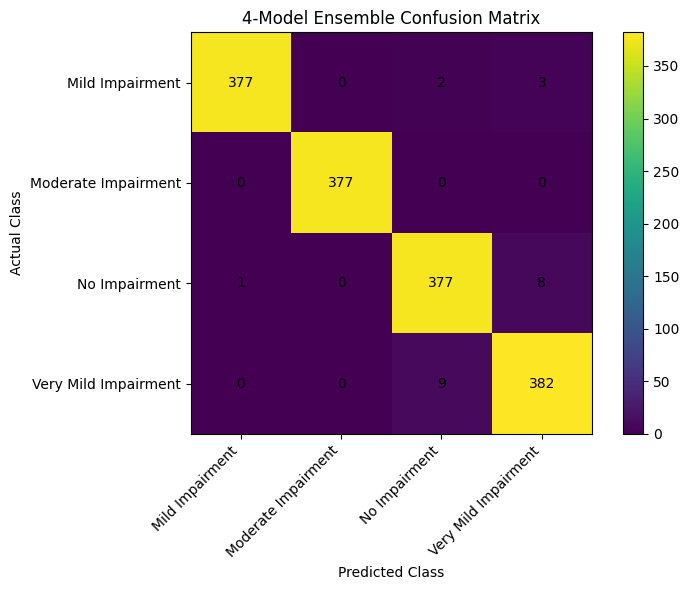

In [37]:
# CELL 13 — Confusion Matrix

cm = confusion_matrix(
    test_y,
    ensemble_pred,
    labels=[0, 1, 2, 3]
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))

plt.imshow(cm, interpolation="nearest")

plt.title("4-Model Ensemble Confusion Matrix")
plt.colorbar()

plt.xticks(
    range(NUM_CLASSES),
    classes,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(NUM_CLASSES),
    classes
)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

In [38]:
# CELL 14 — Save Final Ensemble

import joblib

os.makedirs(RESULTS_PATH, exist_ok=True)

ENSEMBLE_MODEL_PATH = os.path.join(
    MODELS_PATH,
    "ensemble_meta_learner.pkl"
)

ENSEMBLE_INFO_PATH = os.path.join(
    MODELS_PATH,
    "ensemble_info.json"
)

joblib.dump(
    meta_model,
    ENSEMBLE_MODEL_PATH
)

ensemble_info = {
    "models": [
        "ResNet-152",
        "VGG16",
        "EfficientNet-B4",
        "ViT"
    ],
    "input_sizes": {
        "ResNet-152": 224,
        "VGG16": 224,
        "EfficientNet-B4": 380,
        "ViT": 224
    },
    "num_classes": NUM_CLASSES,
    "classes": classes,
    "seed": SEED,
    "validation_samples": len(val_y),
    "test_samples": len(test_y),
    "validation_accuracy": float(val_meta_accuracy),
    "test_accuracy": float(ensemble_accuracy),
    "best_individual_model": best_model,
    "best_individual_accuracy": float(best_accuracy),
    "ensemble_improvement": float(improvement),
    "feature_count": int(test_X.shape[1]),
    "method": "Logistic Regression Stacking"
}

with open(
    ENSEMBLE_INFO_PATH,
    "w"
) as f:
    json.dump(
        ensemble_info,
        f,
        indent=4
    )

print("Ensemble saved successfully.")

print("\nMeta-learner:")
print(ENSEMBLE_MODEL_PATH)

print("\nConfiguration:")
print(ENSEMBLE_INFO_PATH)

print("\nFinal test accuracy:")
print(f"{ensemble_accuracy:.2f}%")

Ensemble saved successfully.

Meta-learner:
models\ensemble_meta_learner.pkl

Configuration:
models\ensemble_info.json

Final test accuracy:
98.50%


In [39]:
# CELL 15 — Reload Ensemble

loaded_meta_model = joblib.load(
    ENSEMBLE_MODEL_PATH
)

reloaded_pred = loaded_meta_model.predict(
    test_X
)

reloaded_accuracy = accuracy_score(
    test_y,
    reloaded_pred
) * 100

print("=" * 60)
print("ENSEMBLE RELOAD VERIFICATION")
print("=" * 60)

print(
    f"Original accuracy : "
    f"{ensemble_accuracy:.2f}%"
)

print(
    f"Reloaded accuracy : "
    f"{reloaded_accuracy:.2f}%"
)

print(
    "Predictions match :",
    np.array_equal(
        ensemble_pred,
        reloaded_pred
    )
)

print(
    "\nReload verification:",
    "PASSED"
    if (
        ensemble_accuracy == reloaded_accuracy
        and np.array_equal(
            ensemble_pred,
            reloaded_pred
        )
    )
    else "FAILED"
)

ENSEMBLE RELOAD VERIFICATION
Original accuracy : 98.50%
Reloaded accuracy : 98.50%
Predictions match : True

Reload verification: PASSED
